In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import tensorflow_text as tf_text  # Registers the ops.
import tensorflow_hub as hub
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from datetime import datetime
import seaborn as sns
import os


In [2]:
dataset_1 = pd.read_csv("GPT-wiki-intro-reformat-20000.csv")
dataset_2 = pd.read_csv("datasets/Training_Essay_Data-reformat.csv")
dataset_3 = pd.read_csv("datasets/train_drcat_01-reformat.csv")
dataset_4 = pd.read_csv("datasets/LLM_generated_essay_PaLM-reformat.csv")
dataset_5 = pd.read_csv("datasets/falcon_180b_v1-reformat.csv")
dataset_6 = pd.read_csv("datasets/llama_70b_v1-reformat.csv")

In [3]:
test_essay = pd.read_csv("LB_test_essays-longer.csv")
test_essay

,id,text,generated
0,1,Cars. Cars have been around since they became ...,0
1,2,Transportation is a large necessity in most co...,0
2,3,"""America's love affair with it's vehicles seem...",0
3,4,How often do you ride in a car? Do you drive a...,0
4,5,Cars are a wonderful thing. They are perhaps o...,0
...,...,...,...
195,196,Advantages of Limiting Car Usage\n\nThe need t...,1
196,197,Limiting car usage has a range of advantages t...,1
197,198,"In recent years, there has been a growing move...",1
198,199,Advantages of Limiting Car Usage\n\nLimiting c...,1


In [4]:
dataset_1 = dataset_1[['text','generated']]

In [5]:
train_data = pd.concat([dataset_1,dataset_2, dataset_3, dataset_4, dataset_5, dataset_6],axis=0,ignore_index=True)
train_data

,text,generated,id
0,Sexhow railway station was a railway station b...,0,NaN
1,"In Finnish folklore, all places and things, an...",0,NaN
2,"In mathematics, specifically differential calc...",0,NaN
3,is a Japanese shōjo manga series written and i...,0,NaN
4,"Robert Milner ""Rob"" Bradley, Jr. (born August ...",0,NaN
...,...,...,...
88237,The issue of climate change has become increas...,0,NaN
88238,"In the article “Driverless Cars are Coming,” t...",0,NaN
88239,The impact of social media on society has been...,0,NaN
88240,There is a growing movement advocating for the...,0,NaN


In [6]:
train_data.drop_duplicates(inplace=True,ignore_index=True)
train_data

,text,generated,id
0,Sexhow railway station was a railway station b...,0,NaN
1,"In Finnish folklore, all places and things, an...",0,NaN
2,"In mathematics, specifically differential calc...",0,NaN
3,is a Japanese shōjo manga series written and i...,0,NaN
4,"Robert Milner ""Rob"" Bradley, Jr. (born August ...",0,NaN
...,...,...,...
80172,Climate change is a really important issue tha...,1,NaN
80173,"Introduction:\n\nDriverless cars, a technology...",1,NaN
80174,Social media has become an integral part of ou...,1,NaN
80175,"Meat, it's something that many of us have grow...",1,NaN


In [7]:
train_data['generated'].value_counts()

generated
0    49248
1    30929
Name: count, dtype: int64

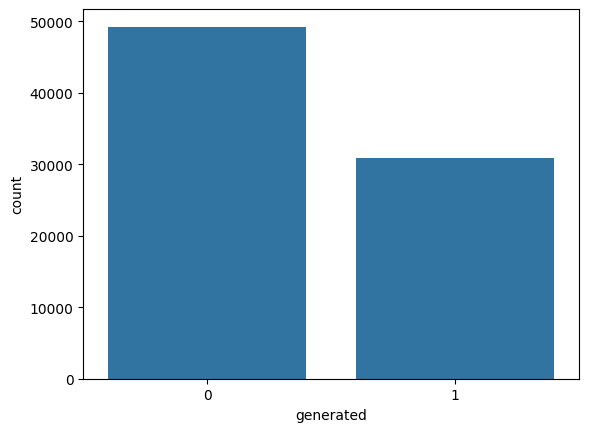

In [8]:
# Check the distribution of the 'source' labels
# Check for class balance
sns.countplot(data=train_data, x='generated')
plt.show()

In [9]:
# function to balance label_counts

def balance_labels(train_data, label_column='generated'):
    label_counts=train_data[label_column].value_counts()
    max_count=label_counts.max()
    balanced_train_data=pd.DataFrame()
    
    for label, count in label_counts.items():
        label_subset = train_data[train_data[label_column]==label]
        oversampled_subset= label_subset.sample(n=(max_count-count), replace=True, random_state=42)
        balanced_train_data = pd.concat([balanced_train_data, label_subset, oversampled_subset], ignore_index=True)
        
    return balanced_train_data


In [10]:
# Balance labels in the dataframe
Train_Data=balance_labels(train_data)

In [11]:
x_train,x_test,y_train,y_test=train_test_split(Train_Data.text,Train_Data.generated,test_size=0.009,shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(97609,)
(887,)
(97609,)
(887,)


In [12]:
# text_input = tf.keras.layers.Input(shape=(), dtype=tf.string)
# preprocessor = hub.KerasLayer(
#     "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
# encoder_inputs = preprocessor(text_input)

In [13]:
# ## Use BERT Model
# encoder = hub.KerasLayer(
#     "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/bert-en-uncased-l-10-h-768-a-12/versions/2",
#     trainable=True)
# outputs = encoder(encoder_inputs)
# pooled_output = outputs['pooled_output'] # [batch_size, 512].
# sequence_output = outputs["sequence_output"] # [batch_size, seq_length, 512].

In [14]:
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string)
preprocessor = hub.KerasLayer(
    "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
encoder_inputs = preprocessor(text_input)

In [15]:
encoder = hub.KerasLayer(
    "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/bert-en-uncased-l-12-h-768-a-12/versions/2",
    trainable=True)
outputs = encoder(encoder_inputs) # Bert model
pooled_output = outputs["pooled_output"]      # [batch_size, 768].
sequence_output = outputs["sequence_output"]  # [batch_size, seq_length, 768].

In [16]:
# text_input = tf.keras.layers.Input(shape=(), dtype=tf.string)
# preprocessor = hub.KerasLayer(
#     "https://kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/en-uncased-preprocess/versions/3")
# encoder_inputs = preprocessor(text_input)
# encoder = hub.KerasLayer(
#     "https://www.kaggle.com/models/tensorflow/bert/frameworks/TensorFlow2/variations/bert-en-uncased-l-10-h-768-a-12/versions/2",
#     trainable=True)
# outputs = encoder(encoder_inputs)
# pooled_output = outputs["pooled_output"]      # [batch_size, 768].
# sequence_output = outputs["sequence_output"]  # [batch_size, seq_length, 768].

In [17]:
dropout = tf.keras.layers.Dropout(0.51 , name="dropout1")(pooled_output)
dense_2 = tf.keras.layers.Dense(64 , activation='relu')(dropout)
dropout = tf.keras.layers.Dropout(0.3 , name="dropout2")(dense_2)

dense_out = tf.keras.layers.Dense(1 , activation='sigmoid', name='output')(dropout)

model = tf.keras.Model(inputs=text_input, outputs=dense_out)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 keras_layer (KerasLayer)       {'input_mask': (Non  0           ['input_1[0][0]']                
                                e, 128),                                                          
                                 'input_type_ids':                                                
                                (None, 128),                                                      
                                 'input_word_ids':                                                
                                (None, 128)}                                                  

In [18]:
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
#               loss='binary_crossentropy',
#               metrics=["acc"])

# checkpoint_filepath = 'checkpoint.hdf5'
# metric = 'val_accuracy'
# callback_list = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, monitor=metric,
#                     verbose=2, save_best_only=True, mode='max')
# history = model.fit(x_train, y_train , batch_size=8, callbacks=[callback_list],epochs=1 , validation_data=(x_test, y_test))
# # model.load_weights(checkpoint_filepath)
# model.save("model-bert")

In [ ]:
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight=sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight=sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))
    
    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

In [ ]:
model_path = "bert-model-saved"

# Check if the saved model exists
if os.path.exists(model_path):
    # Load the pre-trained model
    model = load_model(model_path)
    print("Loaded saved model from:", model_path)
else:
    # If the saved model does not exist, define your model as usual
    # For demonstration, this assumes `model` is already defined somewhere in your script
    # model = ... (Define your model architecture here)

    # Compilation, training, and saving are unchanged
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
                  loss='binary_crossentropy',
              metrics=["acc", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), F1Score()])

    checkpoint_filepath = 'checkpoint.hdf5'
    metric = 'val_accuracy'
    callback_list = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, monitor=metric,
                        verbose=2, save_best_only=True, mode='max')
    
    # Assuming x_train, y_train, x_test, y_test are already defined
    history = model.fit(x_train, y_train, batch_size=8, callbacks=[callback_list], epochs=1, validation_data=(x_test, y_test))

    # No change here, save the model after training
    model.save(model_path)
    print("Model saved at:", model_path)

10186/12202 [========================>.....] - ETA: 8:14 - loss: 0.1810 - acc: 0.9256

In [ ]:
loss , acc = model.evaluate(x_train, y_train)
print("Accuracy on Train data:",acc)
loss , acc = model.evaluate(x_test, y_test)
print("Accuracy on Test data:",acc)

In [ ]:
test_essay

In [ ]:
y_pred = model.predict(test_essay['text'])

In [ ]:
# now = datetime.now()
# formatted_now = now.strftime('%Y-%m-%d_%H-%M-%S')
# filename = f'submission_{formatted_now}.csv'
# Assuming 'test_ids' are the IDs of test samples, and 'predictions' are the predicted values
# converting to the format required for submissions
submission = pd.DataFrame({'id': test_essay['id'] , 'generated': y_pred[:,0], 'text': test_essay['text'] })
# submission.to_csv(filename, index=False)
submission.to_csv('submission.csv', index=False)  # Save the CSV file

In [ ]:
submission_file = pd.read_csv("submission.csv")
submission_file

In [ ]:
# Steganography

In [ ]:
def ascii_to_zwc(value):
    mapping = {
        '00': '\u200B',  # Zero Width Space
        '01': '\u200C',  # Zero Width Non-Joiner
        '10': '\u200D',  # Zero Width Joiner
        '11': '\u2060',  # Word Joiner
    }
    binary_string = format(value, f'012b')  # Convert to 12-bit binary
    zwc_sequence = ''.join(mapping[binary_string[i:i+2]] for i in range(0, len(binary_string), 2))
    return zwc_sequence

In [ ]:
def encode_secret_message(text, secret_message):
    # Initial encoding logic remains unchanged
    bits = 12
    text_length = len(text)
    secret_message_length = len(secret_message)
    interval = text_length // secret_message_length
    encoded_message = ""
    if text_length < secret_message_length:
        print(f"Sorry, not available encoding for this text due to the text length: {text_length} is shorter than the secret message length: {secret_message_length}")
        return None
    else:
        for char in secret_message:
            ascii_value = ord(char)
            transformed_value = ascii_value ^ 170  # Simple XOR for demonstration
            zwc_sequence = ascii_to_zwc(transformed_value)
            encoded_message += zwc_sequence  # Accumulate the encoded characters

    watermarked_text = ""
    last_insert_position = 0
    for i in range(secret_message_length):
        insert_position = (i + 1) * interval if i < secret_message_length - 1 else text_length
        watermarked_text += text[last_insert_position:insert_position] + encoded_message[i * (len(encoded_message) // secret_message_length):(i + 1) * (len(encoded_message) // secret_message_length)]
        last_insert_position = insert_position

    watermarked_text += text[last_insert_position:]

    # Cleaning logic starts here
    # Define known artifacts or characters to remove, if any
    # known_artifacts = ['\u2028', '\u2029','â', '€', 'Œ', '‹', '', '', ' ']  # Example list of artifacts to clean
    # for artifact in known_artifacts:
    #     watermarked_text = watermarked_text.replace(artifact, '')

    # Return the cleaned watermarked text
    return watermarked_text

In [ ]:
def zwc_to_ascii(zwc_sequence):
    reverse_mapping = {
        '\u200B': '00',
        '\u200C': '01',
        '\u200D': '10',
        '\u2060': '11',
    }
    binary_string = ''.join(reverse_mapping[zwc] for zwc in zwc_sequence)
    return int(binary_string, 2)


In [ ]:
def decode_watermarked_text(watermarked_text, secret_message_length):
    # Only process characters that are part of the reverse_mapping
    valid_zwc_characters = {'\u200B', '\u200C', '\u200D', '\u2060'}
    filtered_watermarked_text = ''.join(char for char in watermarked_text if char in valid_zwc_characters)

    # interval = len(filtered_watermarked_text) // (secret_message_length * 6)  # Adjust based on ZWC sequence length per character
    decoded_message = ''

    for i in range(0, len(filtered_watermarked_text), 6):  # Assuming 6 ZWCs per original character
        zwc_sequence = filtered_watermarked_text[i:i + 6]
        if all(zwc in valid_zwc_characters for zwc in zwc_sequence):
            ascii_value = zwc_to_ascii(zwc_sequence)
            original_char = chr(ascii_value ^ 170)  # Reverse XOR operation
            decoded_message += original_char

    return decoded_message

In [ ]:
def apply_encoding_based_on_generated(row):
    secret_message = "Written by Human" if row['generated'] <= 0.5 else "AI generated"
    return encode_secret_message(row['text'], secret_message)

In [ ]:
def apply_decoding_on_generated(row):
    # Determine the secret message based on the same condition used during encoding
    secret_message = "Written by Human" if row['generated'] <= 0.5 else "AI generated"
    # Now you have the secret message for this row and can determine its length
    secret_message_length = len(secret_message)
    # Decode using the encoded text and the determined length
    return decode_watermarked_text(row['watermarked_text'], secret_message_length)

In [ ]:
# Load the CSV file
submission_file = pd.read_csv("submission.csv")
# After encoding and before saving


submission_file['watermarked_text'] = submission_file.apply(apply_encoding_based_on_generated, axis=1)
submission_file['Secret message'] = submission_file.apply(apply_decoding_on_generated, axis=1)
# submission_file['watermarked_text'] = submission_file['watermarked_text'].apply(clean_text)
# Apply encoding based on "generated" column
# submission_file['watermarked_text'] = submission_file.apply(apply_encoding_based_on_generated, axis=1)

submission_file.to_csv("submission_with_steg.csv", mode='w', encoding='utf-8-sig', index=False)